 # Legal Retrieval Evaluation — Detailed Analysis



 This notebook embeds train/test JSON folders into ChromaDB, runs retrieval

 queries, and produces a comprehensive evaluation report with:



 - **Macro & micro metrics** (Precision / Recall / F1)

 - **Score distributions** (histograms, box plots)

 - **Top-N most missed clauses** (frequently in ground truth but not retrieved)

 - **Top-N most redundant clauses** (frequently retrieved but not in ground truth)

 - **Per-clause retrieval rate** (how reliably each clause is found)

 - **Worst & best performing documents**

 - **Retrieval overlap heatmap** (ground truth vs predicted)

 - **Error-pattern co-occurrence** (which missed clauses tend to appear together)

 ## 0. Configuration

 Edit the variables below to match your setup.

In [1]:
# ── User configuration ─────────────────────────────────────────────────────
TRAIN_DIR       = "./chunk/Chuong_XXII_chunked/train"
TEST_DIR        = "./chunk/Chuong_XXII_chunked/synth/split"
TRAIN_DB_DIR    = "./output/chroma_db_train"
TEST_DB_DIR     = "./output/chroma_db_test"

TOP_K           = 5
RESULTS_OUT     = "./output/eval_results_notebook.json"

# Set to True to use existing ChromaDB (skip embedding step)
SKIP_EMBEDDING  = False

# Embedding / chunking parameters
TRAIN_CONTENT_FIELDS = ["Summary", "Tang_nang", "Giam_nhe"]
TEST_CONTENT_FIELDS  = ["Summary"]
MODEL_NAME           = "BAAI/bge-m3"
DEVICE               = "cuda"
MAX_CHUNK_CHARS      = 1500
BATCH_SIZE           = 32
COLLECTION_NAME      = "legal_chunks_vn"

# Analysis parameters
TOP_N = 15  # number of items to show in "top-N" tables


 ## 1. Imports & helpers

In [2]:
import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Local modules
from embedding_store import (
    run_pipeline,
    load_model,
    load_chroma,
)

# Constants from evaluate.py (duplicated here so the notebook is self-contained)
ID_FIELD       = "Ma_Ban_An"
ARTICLES_FIELD = "Cac_Dieu_Quyet_Dinh"


def extract_article_signatures(articles) -> set[str]:
    """Collapse Cac_Dieu_Quyet_Dinh into a flat set of string signatures."""
    sigs = set()
    if isinstance(articles, dict):
        for val_list in articles.values():
            if isinstance(val_list, list):
                for item in val_list:
                    if isinstance(item, list):
                        sigs.add("-".join(str(i) for i in item))
                    else:
                        sigs.add(str(item))
            else:
                sigs.add(str(val_list))
    elif isinstance(articles, list):
        for a in articles:
            if isinstance(a, list):
                sigs.add("-".join(str(i) for i in a))
            else:
                sigs.add(str(a))
    elif articles:
        sigs.add(str(articles))
    return sigs


def load_articles_index(raw_dir: Path) -> dict[str, set[str]]:
    """doc_id -> set of article signatures."""
    index = {}
    for f in raw_dir.glob("*.json"):
        with open(f, encoding="utf-8") as fh:
            data = json.load(fh)
        doc_id = data.get(ID_FIELD, f.stem)
        articles = data.get(ARTICLES_FIELD)
        if articles:
            index[doc_id] = extract_article_signatures(articles)
    return index


def load_test_docs(test_dir: Path, content_fields: list[str]) -> list[dict]:
    """Load test documents with ground truth and query text."""
    test_docs, skipped = [], []
    for f in sorted(test_dir.glob("*.json")):
        with open(f, encoding="utf-8") as fh:
            data = json.load(fh)
        doc_id = data.get(ID_FIELD, f.stem)
        articles = data.get(ARTICLES_FIELD)
        if not articles:
            skipped.append(doc_id)
            continue
        parts = []
        for field in content_fields:
            val = (data.get(field) or "").strip()
            if val:
                parts.append(val)
        query_text = "\n\n".join(parts)
        if not query_text.strip():
            skipped.append(doc_id)
            continue
        test_docs.append({
            "doc_id": doc_id,
            "query_text": query_text,
            "ground_truth": extract_article_signatures(articles),
        })
    if skipped:
        print(f"  [INFO] Skipped {len(skipped)} test doc(s) with missing data: {skipped}")
    return test_docs


def precision_recall_f1(predicted: set[str], ground_truth: set[str]):
    if not predicted and not ground_truth:
        return 1.0, 1.0, 1.0
    if not predicted or not ground_truth:
        return 0.0, 0.0, 0.0
    tp = len(predicted & ground_truth)
    p = tp / len(predicted)
    r = tp / len(ground_truth)
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    return p, r, f1


 ## 2. Embedding (skip if DBs already exist)

In [3]:
if not SKIP_EMBEDDING:
    print("── Embedding train folder ──────────────────────────────────")
    run_pipeline(
        TRAIN_DIR, TRAIN_DB_DIR,
        content_fields=TRAIN_CONTENT_FIELDS,
        model_name=MODEL_NAME, device=DEVICE,
        max_chunk_chars=MAX_CHUNK_CHARS, batch_size=BATCH_SIZE,
        collection_name=COLLECTION_NAME,
    )
    print("\n── Embedding test folder ───────────────────────────────────")
    run_pipeline(
        TEST_DIR, TEST_DB_DIR,
        content_fields=TEST_CONTENT_FIELDS,
        model_name=MODEL_NAME, device=DEVICE,
        max_chunk_chars=MAX_CHUNK_CHARS, batch_size=BATCH_SIZE,
        collection_name=COLLECTION_NAME,
    )
else:
    print("⏭️  Skipping embedding (SKIP_EMBEDDING=True)")


── Embedding train folder ──────────────────────────────────
  Using content fields: ['Summary', 'Tang_nang', 'Giam_nhe']

── Step 1: Chunking ─────────────────────────────────────
  Loaded 860 files → 4829 chunks

── Step 2: Embedding all chunks ─────────────────────────


/home/hieujayce/Downloads/complete_repo/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  Loading BAAI/bge-m3 on cuda ...


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 62723.66it/s]


  Embedding dim: 1024
  0 already in DB, embedding 4829 new chunks ...
  4829/4829 — 306.4s
  Embedding done in 306.4s
  ✅ ChromaDB 'legal_chunks_vn' now has 4829 documents.

── Done ─────────────────────────────────────────────────
  Embedded all chunks in : ./output/chroma_db_train


── Embedding test folder ───────────────────────────────────
  Using content fields: ['Summary']

── Step 1: Chunking ─────────────────────────────────────
  Loaded 84 files → 84 chunks

── Step 2: Embedding all chunks ─────────────────────────
  Loading BAAI/bge-m3 on cuda ...


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 58142.70it/s]


  Embedding dim: 1024
  0 already in DB, embedding 84 new chunks ...
  84/84 — 2.2s
  Embedding done in 2.2s
  ✅ ChromaDB 'legal_chunks_vn' now has 84 documents.

── Done ─────────────────────────────────────────────────
  Embedded all chunks in : ./output/chroma_db_test



 ## 3. Load model & data

In [4]:
print("Loading model ...")
model = load_model(model_name=MODEL_NAME, device=DEVICE)

print("Loading train ChromaDB ...")
collection = load_chroma(TRAIN_DB_DIR, collection_name=COLLECTION_NAME, create=False)
print(f"  Train collection has {collection.count()} documents")

train_path = Path(TRAIN_DIR)
test_path  = Path(TEST_DIR)

train_articles_index = load_articles_index(train_path)
test_docs = load_test_docs(test_path, TEST_CONTENT_FIELDS)
print(f"  {len(test_docs)} evaluable test documents")


Loading model ...
  Loading BAAI/bge-m3 on cuda ...


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 55599.84it/s]


  Embedding dim: 1024
Loading train ChromaDB ...
  Train collection has 4829 documents
  [INFO] Skipped 1 test doc(s) with missing data: ['13-06-2024-Ho_Chi_Minh-2ta1618708t1cvn']
  83 evaluable test documents


 ## 4. Run retrieval & collect per-document results

In [5]:
per_doc_results = []

for doc in test_docs:
    doc_id       = doc["doc_id"]
    query_text   = doc["query_text"]
    ground_truth = doc["ground_truth"]

    vec = model.encode([query_text], normalize_embeddings=True).tolist()

    results = collection.query(
        query_embeddings=vec,
        n_results=TOP_K,
        include=["metadatas", "distances"],
        where={"doc_id": {"$ne": doc_id}},
    )

    # Unique retrieved doc_ids in rank order
    retrieved_doc_ids, seen = [], set()
    distances_per_doc = {}
    for meta, dist in zip(results["metadatas"][0], results["distances"][0]):
        rid = meta["doc_id"]
        if rid not in seen:
            seen.add(rid)
            retrieved_doc_ids.append(rid)
            distances_per_doc[rid] = dist  # keep first (best) distance

    # Union of articles from retrieved docs
    predicted_articles: set[str] = set()
    for rid in retrieved_doc_ids:
        predicted_articles |= train_articles_index.get(rid, set())

    p, r, f1 = precision_recall_f1(predicted_articles, ground_truth)

    per_doc_results.append({
        "doc_id":             doc_id,
        "ground_truth":       sorted(ground_truth),
        "retrieved_doc_ids":  retrieved_doc_ids,
        "distances":          distances_per_doc,
        "predicted_articles": sorted(predicted_articles),
        "matched_articles":   sorted(predicted_articles & ground_truth),
        "missed_articles":    sorted(ground_truth - predicted_articles),
        "extra_articles":     sorted(predicted_articles - ground_truth),
        "precision":          round(p, 4),
        "recall":             round(r, 4),
        "f1":                 round(f1, 4),
        "n_ground_truth":     len(ground_truth),
        "n_predicted":        len(predicted_articles),
        "n_matched":          len(predicted_articles & ground_truth),
        "n_missed":           len(ground_truth - predicted_articles),
        "n_extra":            len(predicted_articles - ground_truth),
    })

print(f"✅ Evaluated {len(per_doc_results)} documents")


✅ Evaluated 83 documents


 ## 5. Macro & Micro Metrics

In [6]:
n = len(per_doc_results)
macro_p  = sum(r["precision"] for r in per_doc_results) / n
macro_r  = sum(r["recall"]    for r in per_doc_results) / n
macro_f1 = sum(r["f1"]        for r in per_doc_results) / n

# Micro: pool all TP/FP/FN across documents
total_matched = sum(r["n_matched"] for r in per_doc_results)
total_pred    = sum(r["n_predicted"] for r in per_doc_results)
total_gt      = sum(r["n_ground_truth"] for r in per_doc_results)
total_missed  = sum(r["n_missed"] for r in per_doc_results)
total_extra   = sum(r["n_extra"] for r in per_doc_results)

micro_p  = total_matched / total_pred if total_pred else 0
micro_r  = total_matched / total_gt   if total_gt   else 0
micro_f1 = 2 * micro_p * micro_r / (micro_p + micro_r) if (micro_p + micro_r) else 0

print("=" * 60)
print(f"  Documents evaluated : {n}")
print(f"  top_k               : {TOP_K}")
print(f"  Model               : {MODEL_NAME}")
print(f"  Content fields      : {TEST_CONTENT_FIELDS}")
print("=" * 60)
print(f"  MACRO  Precision    : {macro_p:.4f}")
print(f"  MACRO  Recall       : {macro_r:.4f}")
print(f"  MACRO  F1           : {macro_f1:.4f}")
print("-" * 60)
print(f"  MICRO  Precision    : {micro_p:.4f}")
print(f"  MICRO  Recall       : {micro_r:.4f}")
print(f"  MICRO  F1           : {micro_f1:.4f}")
print("-" * 60)
print(f"  Total ground truth clauses  : {total_gt}")
print(f"  Total predicted clauses     : {total_pred}")
print(f"  Total matched (TP)          : {total_matched}")
print(f"  Total missed  (FN)          : {total_missed}")
print(f"  Total extra   (FP)          : {total_extra}")
print("=" * 60)


  Documents evaluated : 83
  top_k               : 5
  Model               : BAAI/bge-m3
  Content fields      : ['Summary']
  MACRO  Precision    : 0.3470
  MACRO  Recall       : 0.7055
  MACRO  F1           : 0.4486
------------------------------------------------------------
  MICRO  Precision    : 0.3226
  MICRO  Recall       : 0.6907
  MICRO  F1           : 0.4398
------------------------------------------------------------
  Total ground truth clauses  : 624
  Total predicted clauses     : 1336
  Total matched (TP)          : 431
  Total missed  (FN)          : 193
  Total extra   (FP)          : 905


 ## 6. Score Distributions (Precision / Recall / F1)

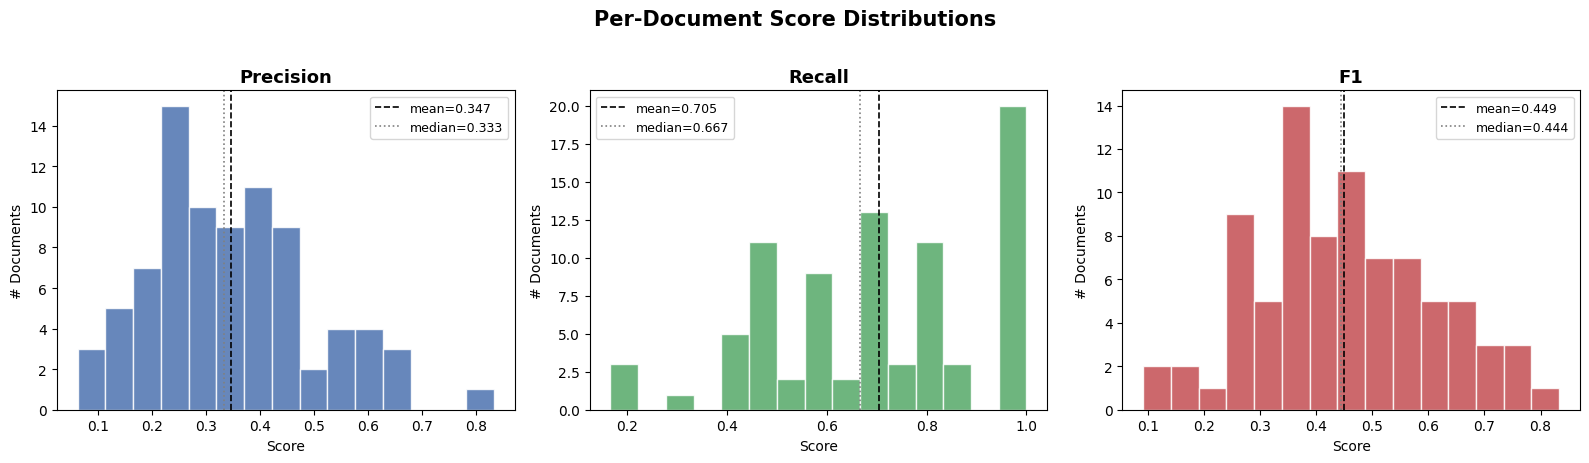

In [7]:
precisions = [r["precision"] for r in per_doc_results]
recalls    = [r["recall"]    for r in per_doc_results]
f1s        = [r["f1"]        for r in per_doc_results]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, data, label, color in zip(
    axes,
    [precisions, recalls, f1s],
    ["Precision", "Recall", "F1"],
    ["#4C72B0", "#55A868", "#C44E52"],
):
    ax.hist(data, bins=15, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(np.mean(data), color="black", linestyle="--", linewidth=1.2,
               label=f"mean={np.mean(data):.3f}")
    ax.axvline(np.median(data), color="gray", linestyle=":", linewidth=1.2,
               label=f"median={np.median(data):.3f}")
    ax.set_title(label, fontsize=13, fontweight="bold")
    ax.set_xlabel("Score")
    ax.set_ylabel("# Documents")
    ax.legend(fontsize=9)

fig.suptitle("Per-Document Score Distributions", fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()


 ## 7. Top-N Most Missed Clauses

 Clauses that appear in ground truth but are **not** retrieved.

 High frequency here means the retrieval system systematically fails to find these.

In [ ]:
missed_counter = Counter()
missed_doc_map = {}  # clause -> list of doc_ids that missed it
for r in per_doc_results:
    for clause in r["missed_articles"]:
        missed_counter[clause] += 1
        missed_doc_map.setdefault(clause, []).append(r["doc_id"])

print(f"{'Rank':<5} {'Clause':<15} {'Times Missed':<15} {'% of Docs':<12} Example Doc IDs")
print("─" * 95)
for rank, (clause, count) in enumerate(missed_counter.most_common(TOP_N), 1):
    pct = count / n * 100
    examples = ", ".join(missed_doc_map[clause][:3])
    if len(missed_doc_map[clause]) > 3:
        examples += " ..."
    print(f"{rank:<5} {clause:<15} {count:<15} {pct:<12.1f} {examples}")


Rank  Clause          Times Missed    % of Docs    Example Doc IDs
───────────────────────────────────────────────────────────────────────────────────────────────
1     47-1-a          11              13.3         11-12-2024-Thanh_Hoa-2ta1778489t1cvn, 18-06-2024-Phu_Tho-2ta1647850t1cvn, 20-03-2024-Dien_Bien-2ta1473104t1cvn ...
2     48-0-0          8               9.6          09-07-2024-Tuyen_Quang-2ta1553282t1cvn, 10-12-2024-Ho_Chi_Minh-2ta1975001t1cvn, 18-01-2024-Ha_Noi-2ta1528796t1cvn ...
3     54-0-0          6               7.2          04-03-2024-Thanh_Hoa-2ta1452048t1cvn, 09-07-2024-Tuyen_Quang-2ta1553282t1cvn, 15-05-2024-Ha_Noi-2ta1493035t1cvn ...
4     38-0-0          6               7.2          12-12-2024-Son_La-2ta1703930t1cvn, 17-06-2024-Dien_Bien-2ta1530585t1cvn, 19-12-2024-Dien_Bien-2ta1708953t1cvn ...
5     46-0-0          6               7.2          15-05-2024-Ha_Noi-2ta1493035t1cvn, 16-09-2024-Ninh_Binh-2ta1660760t1cvn, 18-01-2024-Ha_Noi-2ta1528796t1cvn ...
6     47

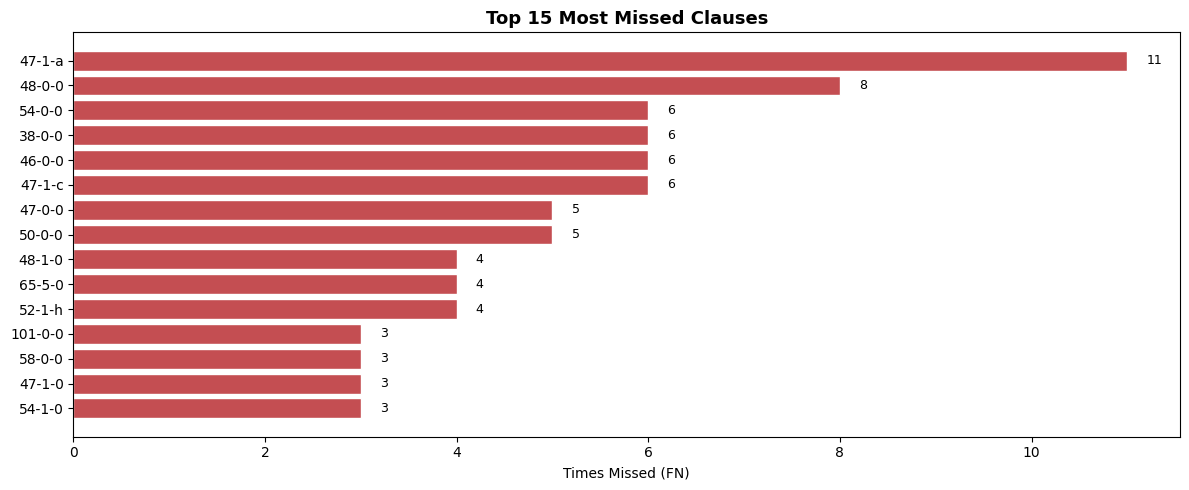

In [9]:
# Bar chart — top missed clauses
top_missed = missed_counter.most_common(TOP_N)
if top_missed:
    fig, ax = plt.subplots(figsize=(12, 5))
    clauses_m = [c for c, _ in top_missed]
    counts_m  = [cnt for _, cnt in top_missed]
    bars = ax.barh(clauses_m[::-1], counts_m[::-1], color="#C44E52", edgecolor="white")
    ax.set_xlabel("Times Missed (FN)")
    ax.set_title(f"Top {TOP_N} Most Missed Clauses", fontsize=13, fontweight="bold")
    for bar, cnt in zip(bars, counts_m[::-1]):
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                str(cnt), va="center", fontsize=9)
    fig.tight_layout()
    plt.show()


 ## 8. Top-N Most Redundant (Extra) Clauses

 Clauses that are retrieved but are **not** in the ground truth.

 High frequency here means these clauses "leak" into results from similar documents.

In [10]:
extra_counter = Counter()
extra_doc_map = {}  # clause -> list of doc_ids
for r in per_doc_results:
    for clause in r["extra_articles"]:
        extra_counter[clause] += 1
        extra_doc_map.setdefault(clause, []).append(r["doc_id"])

print(f"{'Rank':<5} {'Clause':<15} {'Times Extra':<15} {'% of Docs':<12} Example Doc IDs")
print("─" * 95)
for rank, (clause, count) in enumerate(extra_counter.most_common(TOP_N), 1):
    pct = count / n * 100
    examples = ", ".join(extra_doc_map[clause][:3])
    if len(extra_doc_map[clause]) > 3:
        examples += " ..."
    print(f"{rank:<5} {clause:<15} {count:<15} {pct:<12.1f} {examples}")


Rank  Clause          Times Extra     % of Docs    Example Doc IDs
───────────────────────────────────────────────────────────────────────────────────────────────
1     47-0-0          37              44.6         04-11-2024-Hai_Phong-2ta1687712t1cvn, 05-01-2024-Nam_Dinh-2ta1411436t1cvn, 06-08-2024-Ha_Noi-2ta1619973t1cvn ...
2     17-0-0          28              33.7         02-04-2024-Bac_Giang-2ta1657564t1cvn, 02-04-2024-Ha_Tinh-2ta1592402t1cvn, 11-01-2024-Cao_Bang-2ta1406184t1cvn ...
3     38-0-0          28              33.7         02-04-2024-Ha_Tinh-2ta1592402t1cvn, 03-04-2024-Ho_Chi_Minh-2ta1653982t1cvn, 05-01-2024-Nam_Dinh-2ta1411436t1cvn ...
4     47-1-a          27              32.5         02-04-2024-Bac_Giang-2ta1657564t1cvn, 02-04-2024-Ha_Tinh-2ta1592402t1cvn, 04-03-2024-Thanh_Hoa-2ta1452048t1cvn ...
5     58-0-0          27              32.5         02-04-2024-Bac_Giang-2ta1657564t1cvn, 02-04-2024-Ha_Tinh-2ta1592402t1cvn, 10-06-2024-Ho_Chi_Minh-2ta1620367t1cvn ...
6     5

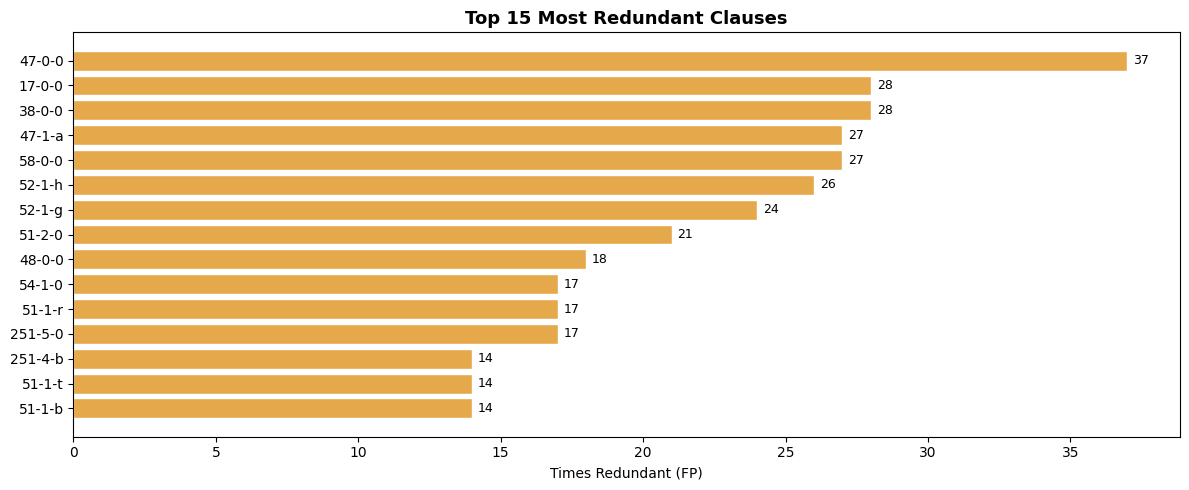

In [11]:
# Bar chart — top redundant clauses
top_extra = extra_counter.most_common(TOP_N)
if top_extra:
    fig, ax = plt.subplots(figsize=(12, 5))
    clauses_e = [c for c, _ in top_extra]
    counts_e  = [cnt for _, cnt in top_extra]
    bars = ax.barh(clauses_e[::-1], counts_e[::-1], color="#E5A84B", edgecolor="white")
    ax.set_xlabel("Times Redundant (FP)")
    ax.set_title(f"Top {TOP_N} Most Redundant Clauses", fontsize=13, fontweight="bold")
    for bar, cnt in zip(bars, counts_e[::-1]):
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                str(cnt), va="center", fontsize=9)
    fig.tight_layout()
    plt.show()


 ## 9. Per-Clause Retrieval Rate

 For each clause that appears in **any** ground truth, what fraction of the

 time is it correctly retrieved?

In [12]:
clause_gt_count   = Counter()  # how many docs have this clause in GT
clause_hit_count  = Counter()  # how many of those docs successfully retrieved it

for r in per_doc_results:
    gt_set  = set(r["ground_truth"])
    hit_set = set(r["matched_articles"])
    for clause in gt_set:
        clause_gt_count[clause] += 1
        if clause in hit_set:
            clause_hit_count[clause] += 1

clause_retrieval_rate = {}
for clause in clause_gt_count:
    total   = clause_gt_count[clause]
    hits    = clause_hit_count.get(clause, 0)
    misses  = total - hits
    rate    = hits / total if total else 0
    clause_retrieval_rate[clause] = {
        "total": total, "hits": hits, "misses": misses, "rate": rate
    }

# Sort by retrieval rate (ascending = hardest to retrieve first)
sorted_by_rate = sorted(clause_retrieval_rate.items(), key=lambda x: (x[1]["rate"], -x[1]["total"]))

print(f"{'Clause':<15} {'GT Count':<10} {'Hits':<8} {'Misses':<8} {'Retrieval Rate'}")
print("─" * 60)
for clause, info in sorted_by_rate[:TOP_N]:
    print(f"{clause:<15} {info['total']:<10} {info['hits']:<8} {info['misses']:<8} "
          f"{info['rate']:.1%}")

print(f"\n... showing {min(TOP_N, len(sorted_by_rate))} of {len(sorted_by_rate)} unique clauses "
      f"(sorted by retrieval rate, ascending)")


Clause          GT Count   Hits     Misses   Retrieval Rate
────────────────────────────────────────────────────────────
46-0-0          6          0        6        0.0%
50-0-0          5          0        5        0.0%
101-0-0         3          0        3        0.0%
47-1-0          3          0        3        0.0%
56-0-0          3          0        3        0.0%
55-1-0          3          0        3        0.0%
51-1-0          2          0        2        0.0%
91-0-0          2          0        2        0.0%
56-2-0          2          0        2        0.0%
47-2-0          2          0        2        0.0%
174-2-c         2          0        2        0.0%
51-2-s          2          0        2        0.0%
51-1-t          2          0        2        0.0%
250-4-h         2          0        2        0.0%
189-3-0         1          0        1        0.0%

... showing 15 of 136 unique clauses (sorted by retrieval rate, ascending)


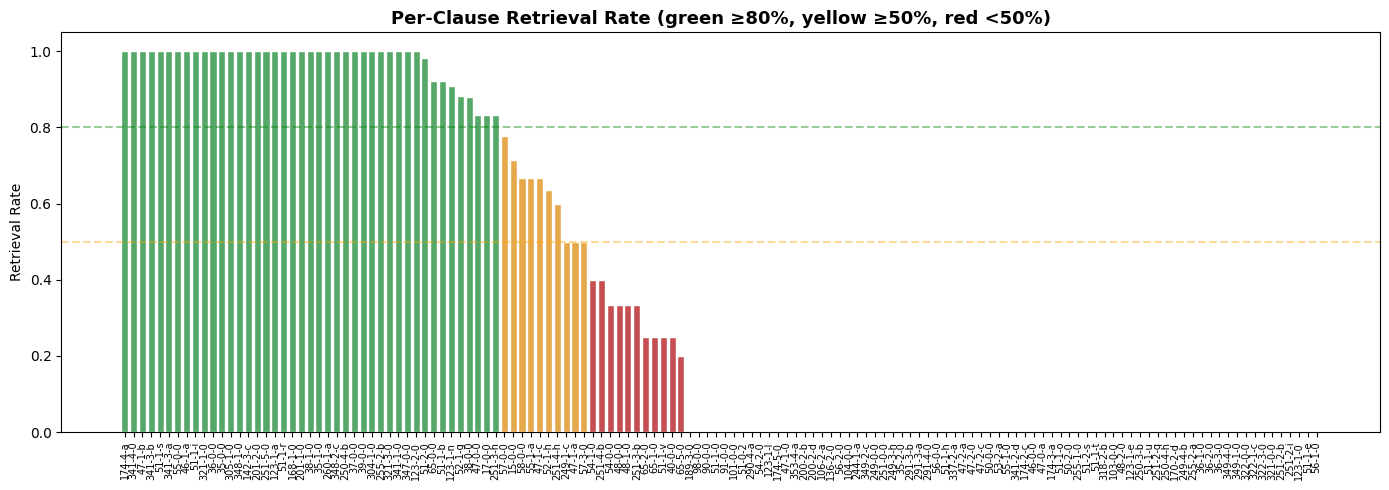

In [13]:
# Plot: retrieval rate per clause (all clauses, sorted)
if clause_retrieval_rate:
    sorted_all = sorted(clause_retrieval_rate.items(),
                        key=lambda x: x[1]["rate"], reverse=True)
    clause_labels = [c for c, _ in sorted_all]
    rates = [info["rate"] for _, info in sorted_all]
    sizes = [info["total"] for _, info in sorted_all]

    fig, ax = plt.subplots(figsize=(14, 5))
    colors_rate = ["#55A868" if r >= 0.8 else "#E5A84B" if r >= 0.5 else "#C44E52"
                   for r in rates]
    ax.bar(range(len(rates)), rates, color=colors_rate, edgecolor="white", width=0.8)
    ax.set_xticks(range(len(rates)))
    ax.set_xticklabels(clause_labels, rotation=90, fontsize=7)
    ax.set_ylabel("Retrieval Rate")
    ax.set_title("Per-Clause Retrieval Rate (green ≥80%, yellow ≥50%, red <50%)",
                 fontsize=13, fontweight="bold")
    ax.axhline(0.8, color="green", linestyle="--", alpha=0.4)
    ax.axhline(0.5, color="orange", linestyle="--", alpha=0.4)
    ax.set_ylim(0, 1.05)
    fig.tight_layout()
    plt.show()


 ## 10. Worst & Best Performing Documents

In [14]:
sorted_by_f1 = sorted(per_doc_results, key=lambda r: r["f1"])

print("=" * 90)
print("  WORST performing documents (lowest F1)")
print("=" * 90)
print(f"{'Rank':<5} {'Doc ID':<50} {'P':<8} {'R':<8} {'F1':<8} Missed")
print("─" * 90)
for rank, r in enumerate(sorted_by_f1[:TOP_N], 1):
    missed_str = ", ".join(r["missed_articles"][:5])
    if len(r["missed_articles"]) > 5:
        missed_str += f" ... (+{len(r['missed_articles'])-5})"
    print(f"{rank:<5} {r['doc_id']:<50} {r['precision']:<8.4f} "
          f"{r['recall']:<8.4f} {r['f1']:<8.4f} {missed_str}")

print()
print("=" * 90)
print("  BEST performing documents (highest F1)")
print("=" * 90)
print(f"{'Rank':<5} {'Doc ID':<50} {'P':<8} {'R':<8} {'F1':<8} #GT  #Pred")
print("─" * 90)
for rank, r in enumerate(sorted(per_doc_results, key=lambda r: -r["f1"])[:TOP_N], 1):
    print(f"{rank:<5} {r['doc_id']:<50} {r['precision']:<8.4f} "
          f"{r['recall']:<8.4f} {r['f1']:<8.4f} "
          f"{r['n_ground_truth']:<5}{r['n_predicted']}")


  WORST performing documents (lowest F1)
Rank  Doc ID                                             P        R        F1       Missed
──────────────────────────────────────────────────────────────────────────────────────────
1     26-03-2024-Dien_Bien-2ta1467643t1cvn               0.0625   0.1667   0.0909   250-4-h, 40-0-0, 47-1-a, 47-1-c, 52-1-h
2     19-12-2024-Dien_Bien-2ta1708953t1cvn               0.0909   0.2000   0.1250   251-2-q, 251-4-h, 38-0-0, 47-1-0
3     02-04-2024-Ha_Tinh-2ta1592402t1cvn                 0.1111   0.2222   0.1481   101-0-0, 189-3-0, 51-0-2, 51-1-0, 90-0-0 ... (+2)
4     20-03-2024-Dien_Bien-2ta1473104t1cvn               0.1176   0.4000   0.1818   250-4-h, 47-1-a, 47-1-c
5     27-06-2024-Son_La-2ta1556982t1cvn                  0.1250   0.5000   0.2000   251-3-b, 47-1-a, 47-1-c
6     15-08-2024-Dien_Bien-2ta1594374t1cvn               0.1600   0.5000   0.2424   174-3-a, 47-0-a, 48-1-0, 52-1-g
7     12-11-2024-Cao_Bang-2ta1689860t1cvn                0.1481   0.80

 ## 12. Ground-Truth Size vs Recall

 Do documents with more clauses tend to have lower recall?

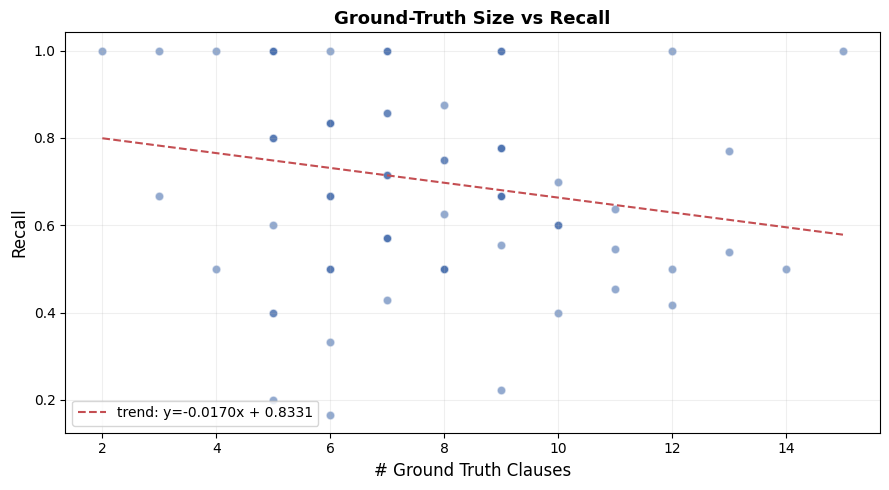

In [16]:
gt_sizes  = [r["n_ground_truth"] for r in per_doc_results]
doc_recalls = [r["recall"] for r in per_doc_results]

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(gt_sizes, doc_recalls, alpha=0.6, s=40, color="#4C72B0", edgecolors="white")
# trend line
z = np.polyfit(gt_sizes, doc_recalls, 1)
p_line = np.poly1d(z)
xs = np.linspace(min(gt_sizes), max(gt_sizes), 100)
ax.plot(xs, p_line(xs), "--", color="#C44E52", linewidth=1.5,
        label=f"trend: y={z[0]:.4f}x + {z[1]:.4f}")
ax.set_xlabel("# Ground Truth Clauses", fontsize=12)
ax.set_ylabel("Recall", fontsize=12)
ax.set_title("Ground-Truth Size vs Recall", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()


 ## 13. Missed-Clause Co-occurrence

 Which clauses tend to be missed **together**? Highlights systematic gaps.

In [17]:
from itertools import combinations

co_occur = Counter()
for r in per_doc_results:
    missed = sorted(r["missed_articles"])
    if len(missed) >= 2:
        for pair in combinations(missed, 2):
            co_occur[pair] += 1

if co_occur:
    print(f"{'Rank':<5} {'Clause Pair':<30} {'Co-occurrences':<15}")
    print("─" * 55)
    for rank, (pair, count) in enumerate(co_occur.most_common(TOP_N), 1):
        print(f"{rank:<5} {str(pair):<30} {count}")
else:
    print("No missed-clause co-occurrences found (all documents have ≤1 miss).")


Rank  Clause Pair                    Co-occurrences 
───────────────────────────────────────────────────────
1     ('47-1-a', '47-1-c')           6
2     ('65-1-0', '65-2-0')           3
3     ('65-1-0', '65-5-0')           3
4     ('65-2-0', '65-5-0')           3
5     ('101-0-0', '91-0-0')          2
6     ('54-0-0', '57-0-0')           2
7     ('48-0-0', '54-0-0')           2
8     ('46-0-0', '54-0-0')           2
9     ('47-0-0', '50-0-0')           2
10    ('52-1-h', '55-1-0')           2
11    ('46-0-0', '48-0-0')           2
12    ('47-1-a', '48-0-0')           2
13    ('51-1-v', '54-0-0')           2
14    ('250-4-h', '47-1-a')          2
15    ('250-4-h', '47-1-c')          2


 ## 14. Retrieval Distance Statistics

 How close are the retrieved documents in embedding space?

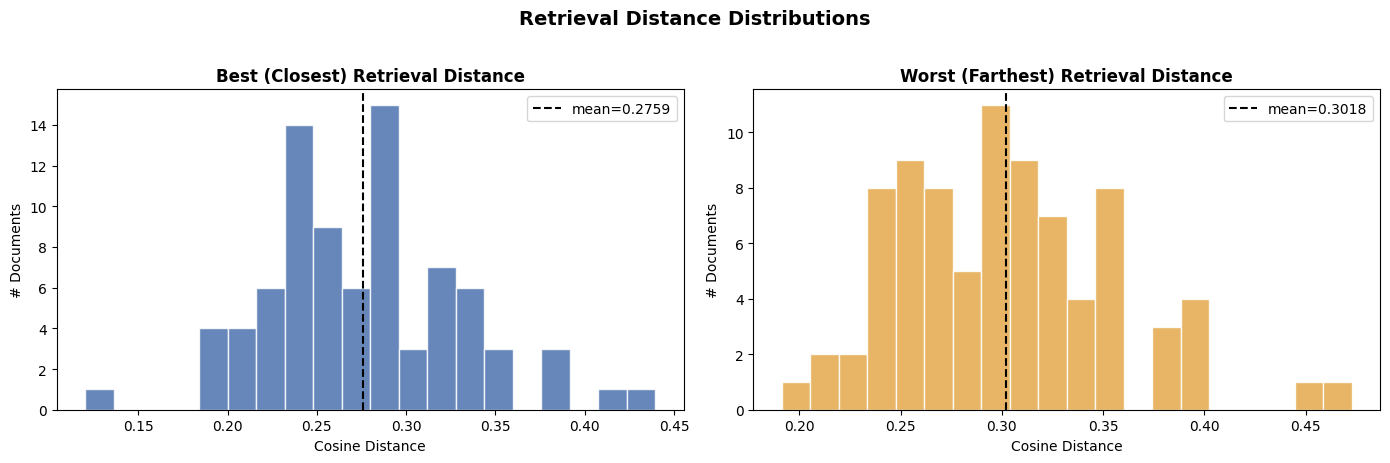

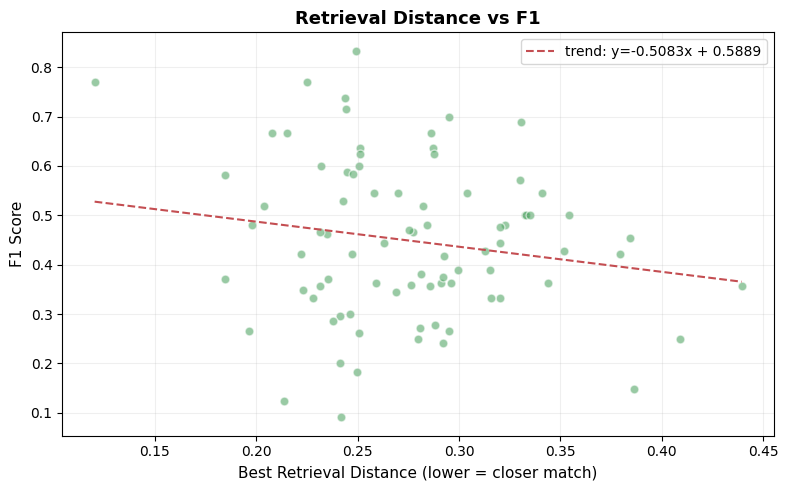

In [18]:
all_best_dists = []
all_worst_dists = []

for r in per_doc_results:
    dists = list(r["distances"].values())
    if dists:
        all_best_dists.append(min(dists))
        all_worst_dists.append(max(dists))

if all_best_dists:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    axes[0].hist(all_best_dists, bins=20, color="#4C72B0", edgecolor="white", alpha=0.85)
    axes[0].axvline(np.mean(all_best_dists), color="black", linestyle="--",
                    label=f"mean={np.mean(all_best_dists):.4f}")
    axes[0].set_title("Best (Closest) Retrieval Distance", fontsize=12, fontweight="bold")
    axes[0].set_xlabel("Cosine Distance")
    axes[0].set_ylabel("# Documents")
    axes[0].legend()

    axes[1].hist(all_worst_dists, bins=20, color="#E5A84B", edgecolor="white", alpha=0.85)
    axes[1].axvline(np.mean(all_worst_dists), color="black", linestyle="--",
                    label=f"mean={np.mean(all_worst_dists):.4f}")
    axes[1].set_title("Worst (Farthest) Retrieval Distance", fontsize=12, fontweight="bold")
    axes[1].set_xlabel("Cosine Distance")
    axes[1].set_ylabel("# Documents")
    axes[1].legend()

    fig.suptitle("Retrieval Distance Distributions", fontsize=14, fontweight="bold", y=1.02)
    fig.tight_layout()
    plt.show()

    # Correlation: distance vs F1
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(all_best_dists, f1s, alpha=0.6, s=40, color="#55A868", edgecolors="white")
    z = np.polyfit(all_best_dists, f1s, 1)
    p_line = np.poly1d(z)
    xs = np.linspace(min(all_best_dists), max(all_best_dists), 100)
    ax.plot(xs, p_line(xs), "--", color="#C44E52", linewidth=1.5,
            label=f"trend: y={z[0]:.4f}x + {z[1]:.4f}")
    ax.set_xlabel("Best Retrieval Distance (lower = closer match)", fontsize=11)
    ax.set_ylabel("F1 Score", fontsize=11)
    ax.set_title("Retrieval Distance vs F1", fontsize=13, fontweight="bold")
    ax.legend()
    ax.grid(alpha=0.2)
    fig.tight_layout()
    plt.show()


 ## 15. Per-Document # Retrieved Unique Docs

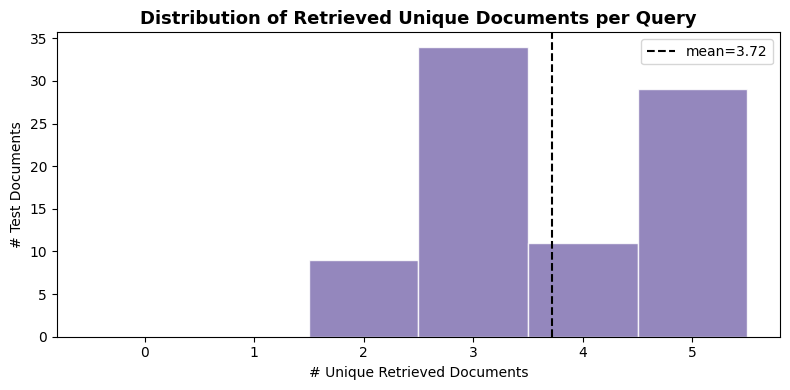

In [19]:
n_retrieved = [len(r["retrieved_doc_ids"]) for r in per_doc_results]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(n_retrieved, bins=range(0, max(n_retrieved) + 2), color="#8172B2",
        edgecolor="white", alpha=0.85, align="left")
ax.set_xlabel("# Unique Retrieved Documents")
ax.set_ylabel("# Test Documents")
ax.set_title("Distribution of Retrieved Unique Documents per Query", fontsize=13, fontweight="bold")
ax.axvline(np.mean(n_retrieved), color="black", linestyle="--",
           label=f"mean={np.mean(n_retrieved):.2f}")
ax.legend()
fig.tight_layout()
plt.show()


 ## 16. Perfect Recall vs Imperfect Recall Breakdown

In [20]:
perfect_recall_docs   = [r for r in per_doc_results if r["recall"] == 1.0]
imperfect_recall_docs = [r for r in per_doc_results if r["recall"] < 1.0]
zero_recall_docs      = [r for r in per_doc_results if r["recall"] == 0.0]

print(f"  Perfect recall (R=1.0)   : {len(perfect_recall_docs):>4}  ({len(perfect_recall_docs)/n*100:.1f}%)")
print(f"  Imperfect recall (R<1.0) : {len(imperfect_recall_docs):>4}  ({len(imperfect_recall_docs)/n*100:.1f}%)")
print(f"  Zero recall (R=0.0)      : {len(zero_recall_docs):>4}  ({len(zero_recall_docs)/n*100:.1f}%)")

if perfect_recall_docs:
    avg_precision_perfect = np.mean([r["precision"] for r in perfect_recall_docs])
    print(f"\n  Among perfect-recall docs: avg precision = {avg_precision_perfect:.4f}")
    print(f"    → avg {np.mean([r['n_extra'] for r in perfect_recall_docs]):.1f} extra clauses per doc")

if imperfect_recall_docs:
    avg_recall_imperfect = np.mean([r["recall"] for r in imperfect_recall_docs])
    avg_missed = np.mean([r["n_missed"] for r in imperfect_recall_docs])
    print(f"\n  Among imperfect-recall docs: avg recall = {avg_recall_imperfect:.4f}")
    print(f"    → avg {avg_missed:.1f} missed clauses per doc")


  Perfect recall (R=1.0)   :   20  (24.1%)
  Imperfect recall (R<1.0) :   63  (75.9%)
  Zero recall (R=0.0)      :    0  (0.0%)

  Among perfect-recall docs: avg precision = 0.4288
    → avg 9.1 extra clauses per doc

  Among imperfect-recall docs: avg recall = 0.6120
    → avg 3.1 missed clauses per doc


 ## 17. Save full results to JSON

In [21]:
output = {
    "config": {
        "train_dir":    TRAIN_DIR,
        "test_dir":     TEST_DIR,
        "train_db_dir": TRAIN_DB_DIR,
        "test_db_dir":  TEST_DB_DIR,
        "top_k":        TOP_K,
        "model_name":   MODEL_NAME,
        "device":       DEVICE,
        "max_chunk_chars":     MAX_CHUNK_CHARS,
        "collection_name":     COLLECTION_NAME,
        "train_content_fields": TRAIN_CONTENT_FIELDS,
        "test_content_fields":  TEST_CONTENT_FIELDS,
    },
    "summary": {
        "n_docs":           n,
        "macro_precision":  round(macro_p, 4),
        "macro_recall":     round(macro_r, 4),
        "macro_f1":         round(macro_f1, 4),
        "micro_precision":  round(micro_p, 4),
        "micro_recall":     round(micro_r, 4),
        "micro_f1":         round(micro_f1, 4),
        "total_gt":         total_gt,
        "total_predicted":  total_pred,
        "total_matched":    total_matched,
        "total_missed":     total_missed,
        "total_extra":      total_extra,
        "perfect_recall_count":   len(perfect_recall_docs),
        "imperfect_recall_count": len(imperfect_recall_docs),
        "zero_recall_count":      len(zero_recall_docs),
    },
    "top_missed_clauses": [
        {"clause": c, "count": cnt, "pct": round(cnt / n * 100, 2)}
        for c, cnt in missed_counter.most_common(TOP_N)
    ],
    "top_extra_clauses": [
        {"clause": c, "count": cnt, "pct": round(cnt / n * 100, 2)}
        for c, cnt in extra_counter.most_common(TOP_N)
    ],
    "clause_retrieval_rates": {
        clause: {
            "gt_count": info["total"],
            "hits": info["hits"],
            "misses": info["misses"],
            "rate": round(info["rate"], 4),
        }
        for clause, info in sorted(clause_retrieval_rate.items(),
                                    key=lambda x: x[1]["rate"])
    },
    "per_doc": [
        {k: v for k, v in r.items() if k != "distances"}
        for r in per_doc_results
    ],
}

out_path = Path(RESULTS_OUT)
out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, "w", encoding="utf-8") as fh:
    json.dump(output, fh, ensure_ascii=False, indent=2)

print(f"\n✅ Full results saved to: {out_path}")



✅ Full results saved to: output/eval_results_notebook.json


 ## 17. Law Clauses Analysis (TEST vs TRAIN)

 Identification of clauses present in the test set but entirely missing from the training set index.

In [ ]:
train_path = Path(TRAIN_DIR)
test_path  = Path(TEST_DIR)

train_articles_index = load_articles_index(train_path)
test_articles_index = load_articles_index(test_path)

all_train_clauses = set()
for clauses in train_articles_index.values():
    all_train_clauses.update(clauses)

all_test_clauses = set()
for clauses in test_articles_index.values():
    all_test_clauses.update(clauses)

unique_to_test = all_test_clauses - all_train_clauses

print(f"Total unique clauses in TRAIN_DIR: {len(all_train_clauses)}")
print(f"Total unique clauses in TEST_DIR: {len(all_test_clauses)}")
print(f"Number of law clauses in TEST_DIR but not in TRAIN_DIR: {len(unique_to_test)}")
if len(unique_to_test) > 0:
    print(f"\nClauses present in TEST but missing from TRAIN index:\n{sorted(list(unique_to_test))}")

 ## 18. Summary



 | Metric | Macro | Micro |

 |--------|-------|-------|

 | Precision | `macro_p` | `micro_p` |

 | Recall | `macro_r` | `micro_r` |

 | F1 | `macro_f1` | `micro_f1` |



 See the saved JSON for full per-document results, per-clause retrieval

 rates, and error analysis data.